# Problem Set 02 — Bank Marketing Prediction using Logistic Regression

## Objective
A banking institution wants to predict whether a customer will subscribe to a **term deposit** (`yes`) or not (`no`) using the customer's demographic and banking information.

This notebook uses the **Bank Marketing Data Set** (`bank-full.csv`) and builds a **Logistic Regression** classification model.

### Tasks covered
1. Load and inspect the dataset
2. Perform exploratory data analysis (EDA)
3. Check missing values and duplicate records
4. Separate features and target
5. Split the data into training and testing sets
6. Preprocess numerical and categorical features
7. Train a Logistic Regression model
8. Evaluate the model using accuracy, precision, recall, F1-score, confusion matrix and ROC-AUC
9. Plot the ROC curve
10. Interpret important model coefficients
11. Demonstrate prediction for new customers


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

RANDOM_STATE = 42
DATA_PATH = "bank-full.csv"

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Load the Dataset

The CSV file uses `;` as its separator, so it is specified explicitly when reading the file.

In [2]:
df = pd.read_csv(DATA_PATH, sep=";")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 2. Understand the Dataset

The dataset contains **45,211 records and 17 columns**. The target variable is `y`:
- `yes` → customer subscribed to a term deposit
- `no` → customer did not subscribe


In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset information:")
df.info()


Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Data types:


,Data Type
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


## 3. Descriptive Statistics

In [4]:
display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


## 4. Missing Values and Duplicate Records

In [5]:
print("Missing values in each column:")
display(df.isnull().sum().to_frame("Missing Values"))

print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())


Missing values in each column:


,Missing Values
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


Total missing values: 0
Duplicate rows: 0


## 5. Exploratory Data Analysis

Because the target classes are not evenly distributed, we first inspect the number of customers who subscribed versus those who did not.


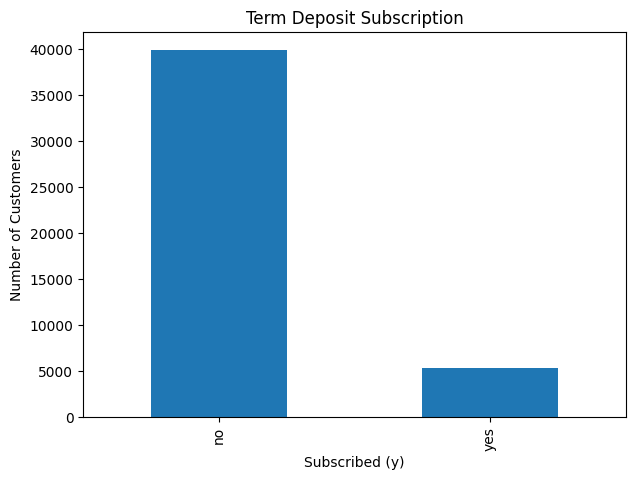

Target distribution:


,Count
y,
no,39922
yes,5289


,Percentage
y,
no,88.3
yes,11.7


In [6]:
plt.figure(figsize=(7, 5))
df["y"].value_counts().reindex(["no", "yes"]).plot(kind="bar")
plt.title("Term Deposit Subscription")
plt.xlabel("Subscribed (y)")
plt.ylabel("Number of Customers")
plt.show()

print("Target distribution:")
display(df["y"].value_counts().to_frame("Count"))
display((df["y"].value_counts(normalize=True) * 100).round(2).to_frame("Percentage"))


### Distribution of selected numerical features

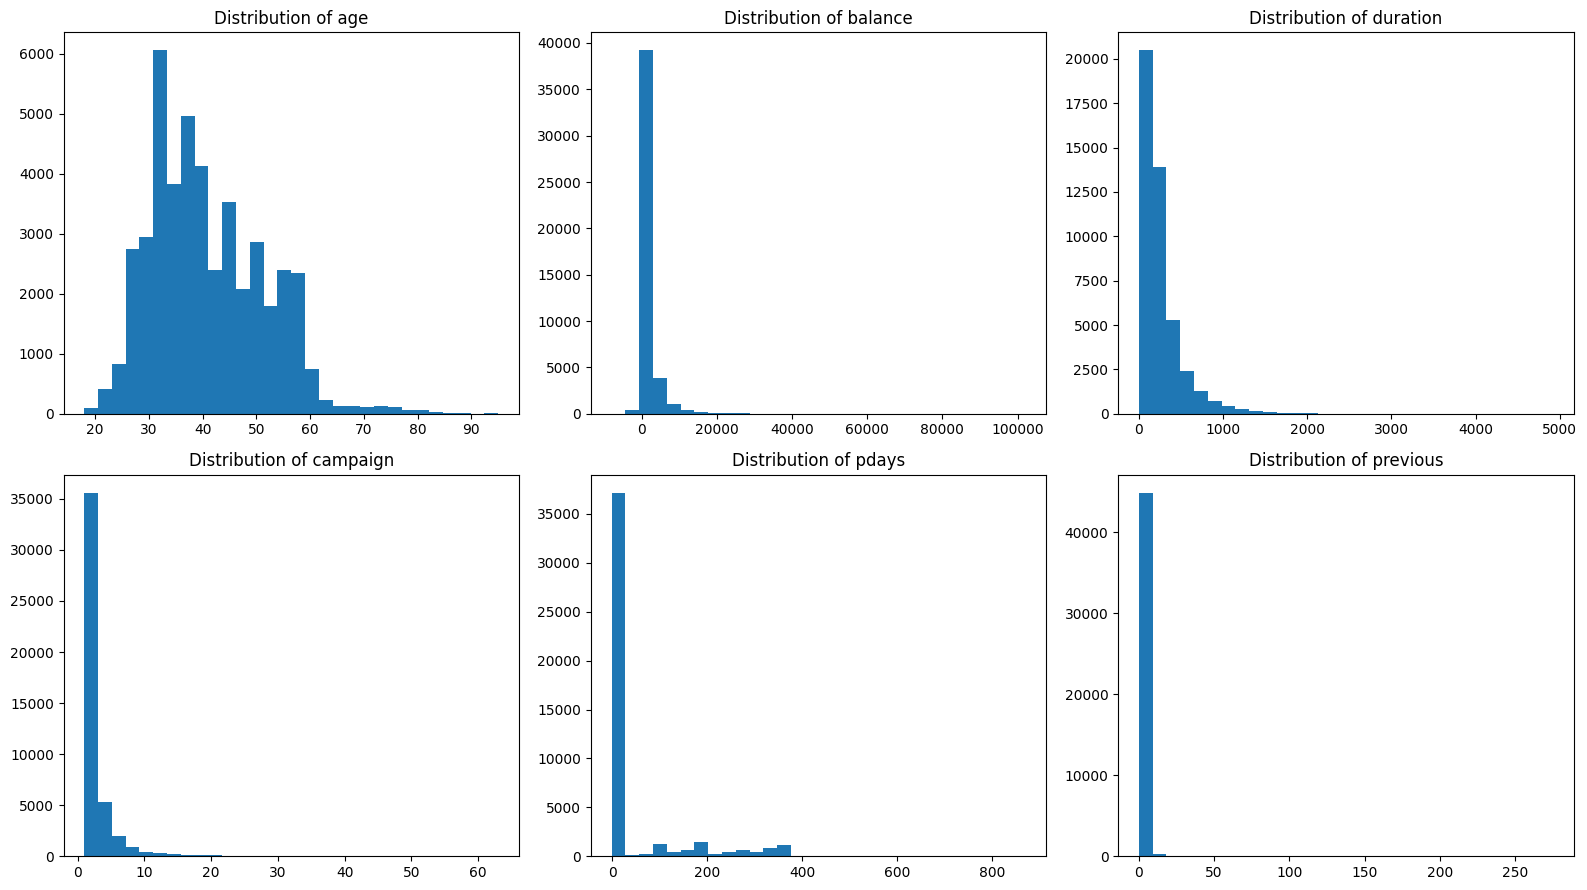

In [7]:
numeric_for_plot = ["age", "balance", "duration", "campaign", "pdays", "previous"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), numeric_for_plot):
    ax.hist(df[col], bins=30)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


### Subscription rate by selected categorical variables

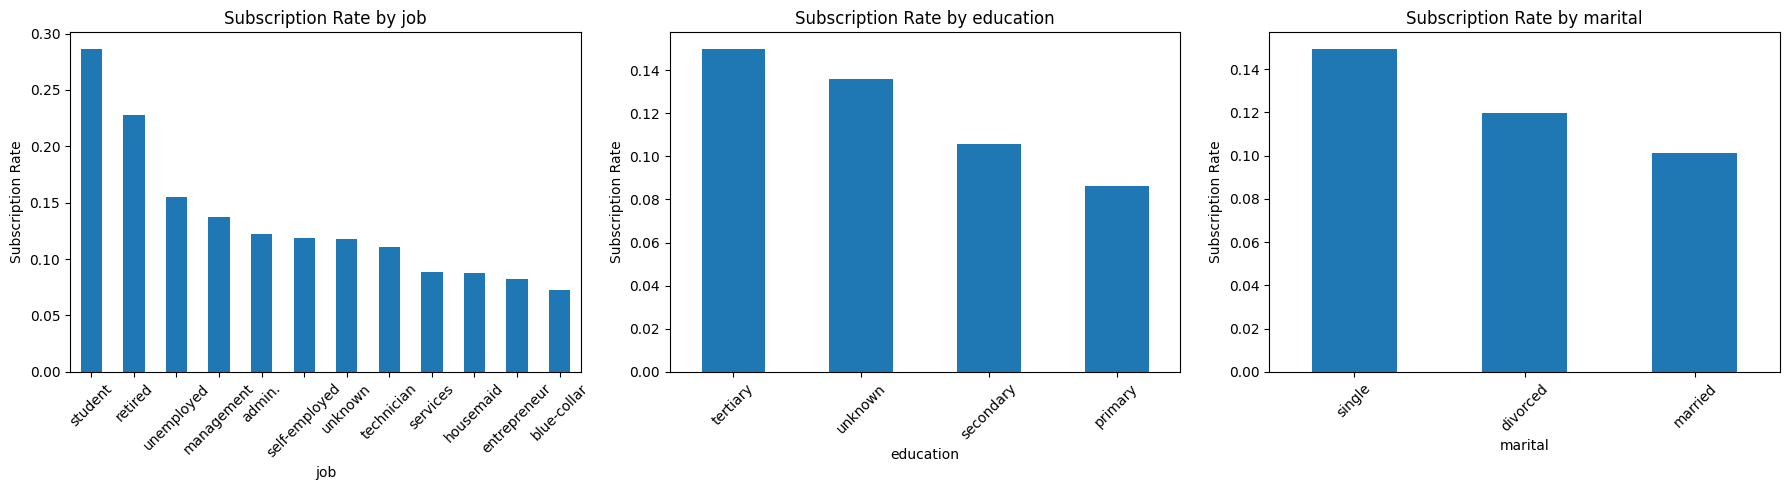

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["job", "education", "marital"]):
    rate = df.groupby(col)["y"].apply(lambda x: (x == "yes").mean()).sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax)
    ax.set_title(f"Subscription Rate by {col}")
    ax.set_ylabel("Subscription Rate")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 6. Prepare Features and Target

The target variable `y` is converted to binary form:
- `no = 0`
- `yes = 1`

Categorical predictors are one-hot encoded. Numerical predictors are standardized so that variables with larger numerical scales do not dominate the optimization.


In [9]:
X = df.drop(columns="y").copy()
y = df["y"].map({"no": 0, "yes": 1})

print("Target values after encoding:")
print(y.value_counts())


Target values after encoding:
y
0    39922
1     5289
Name: count, dtype: int64


## 7. Train-Test Split

A stratified 80/20 split is used so that the proportion of subscribed customers remains approximately the same in both sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).round(4).to_frame("Proportion"))

print("Testing target distribution:")
display(y_test.value_counts(normalize=True).round(4).to_frame("Proportion"))


Training samples: 36168
Testing samples : 9043

Training target distribution:


,Proportion
y,
0,0.883
1,0.117


Testing target distribution:


,Proportion
y,
0,0.883
1,0.117


## 8. Data Preprocessing

We identify numerical and categorical columns automatically. Numerical features are standardized, while categorical features are converted into binary indicator variables using One-Hot Encoding.

In [11]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", numeric_features)
print("\nCategorical features:", categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


Numerical features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## 9. Build the Logistic Regression Pipeline

The preprocessing and classifier are combined into one pipeline. This prevents accidental data leakage because preprocessing parameters are learned only from the training data.

In [12]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]
)

logistic_model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 10. Train the Logistic Regression Model

In [13]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


## 11. Make Predictions

Logistic Regression produces a probability between 0 and 1. With the default threshold of **0.50**:
- probability ≥ 0.50 → `yes`
- probability < 0.50 → `no`


In [14]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("First 10 predicted probabilities:")
print(np.round(y_prob[:10], 4))

print("\nFirst 10 predicted classes:")
print(y_pred[:10])


First 10 predicted probabilities:
[0.0074 0.0108 0.0194 0.005  0.0418 0.0337 0.0182 0.9744 0.0363 0.0404]

First 10 predicted classes:
[0 0 0 0 0 0 0 1 0 0]


## 12. Model Evaluation

We use several evaluation metrics:

- **Accuracy:** overall proportion of correct predictions.
- **Precision:** among customers predicted as subscribers, how many actually subscribed.
- **Recall:** among actual subscribers, how many were correctly identified.
- **F1-score:** harmonic mean of precision and recall.
- **ROC-AUC:** measures how well the model separates the two classes across different thresholds.


In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

display(results.style.format({"Score": "{:.4f}"}))

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["No Subscription", "Subscription"],
    digits=4
))


,Metric,Score
0,Accuracy,0.9012
1,Precision,0.6445
2,Recall,0.3478
3,F1-Score,0.4518
4,ROC-AUC,0.9056



Classification Report:
                 precision    recall  f1-score   support

No Subscription     0.9186    0.9746    0.9457      7985
   Subscription     0.6445    0.3478    0.4518      1058

       accuracy                         0.9012      9043
      macro avg     0.7815    0.6612    0.6988      9043
   weighted avg     0.8865    0.9012    0.8879      9043



## 13. Confusion Matrix

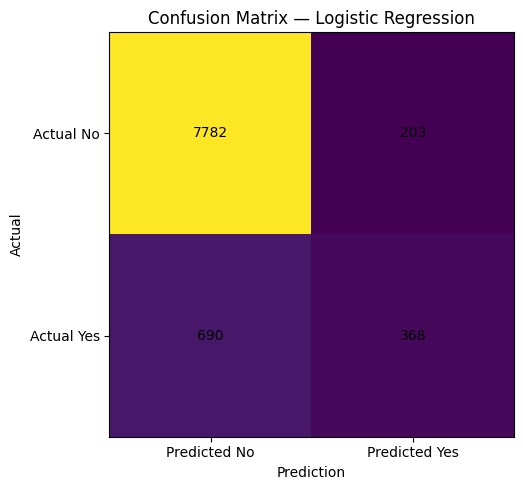

True Negatives : 7782
False Positives: 203
False Negatives: 690
True Positives : 368


In [16]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm)
ax.set_xticks([0, 1], ["Predicted No", "Predicted Yes"])
ax.set_yticks([0, 1], ["Actual No", "Actual Yes"])
ax.set_title("Confusion Matrix — Logistic Regression")
ax.set_xlabel("Prediction")
ax.set_ylabel("Actual")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

## 14. ROC Curve

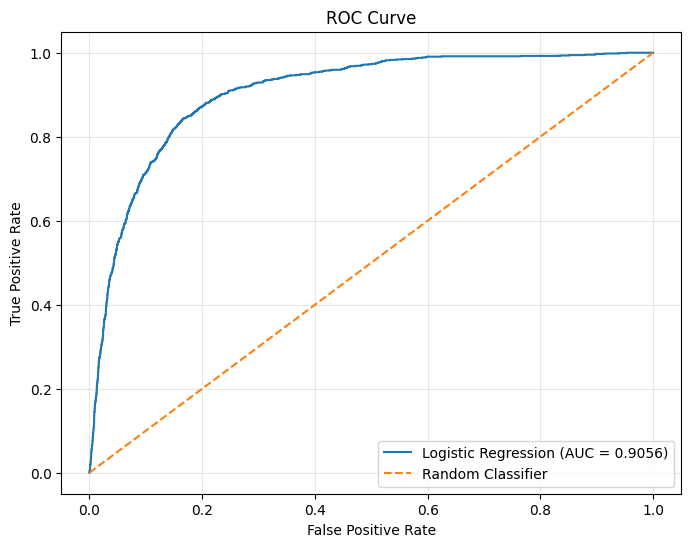

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 15. Interpreting Logistic Regression Coefficients

For Logistic Regression:
- A **positive coefficient** increases the log-odds of subscribing.
- A **negative coefficient** decreases the log-odds of subscribing.
- Larger absolute coefficient values indicate a stronger relationship with the prediction, after preprocessing.

The coefficients below describe the model's learned relationships; they should not be interpreted as causal effects.


In [18]:
feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = logistic_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})
coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()

print("Top 15 positive coefficients:")
display(
    coef_df.sort_values("Coefficient", ascending=False)
           .head(15)[["Feature", "Coefficient"]]
           .reset_index(drop=True)
)

print("Top 15 negative coefficients:")
display(
    coef_df.sort_values("Coefficient", ascending=True)
           .head(15)[["Feature", "Coefficient"]]
           .reset_index(drop=True)
)


Top 15 positive coefficients:


,Feature,Coefficient
0,cat__poutcome_success,1.549282
1,cat__month_mar,1.457573
2,num__duration,1.091874
3,cat__month_sep,0.816278
4,cat__month_oct,0.776825
5,cat__month_dec,0.623754
6,cat__job_student,0.454125
7,cat__job_retired,0.416891
8,cat__month_jun,0.399856
9,cat__contact_cellular,0.390963


Top 15 negative coefficients:


,Feature,Coefficient
0,cat__month_jan,-1.321511
1,cat__contact_unknown,-1.201578
2,cat__month_nov,-0.927599
3,cat__month_jul,-0.883044
4,cat__poutcome_failure,-0.792804
5,cat__poutcome_unknown,-0.778145
6,cat__month_aug,-0.765472
7,cat__housing_yes,-0.607777
8,cat__poutcome_other,-0.517490
9,cat__loan_yes,-0.487028


## 16. Visualize the Most Important Coefficients

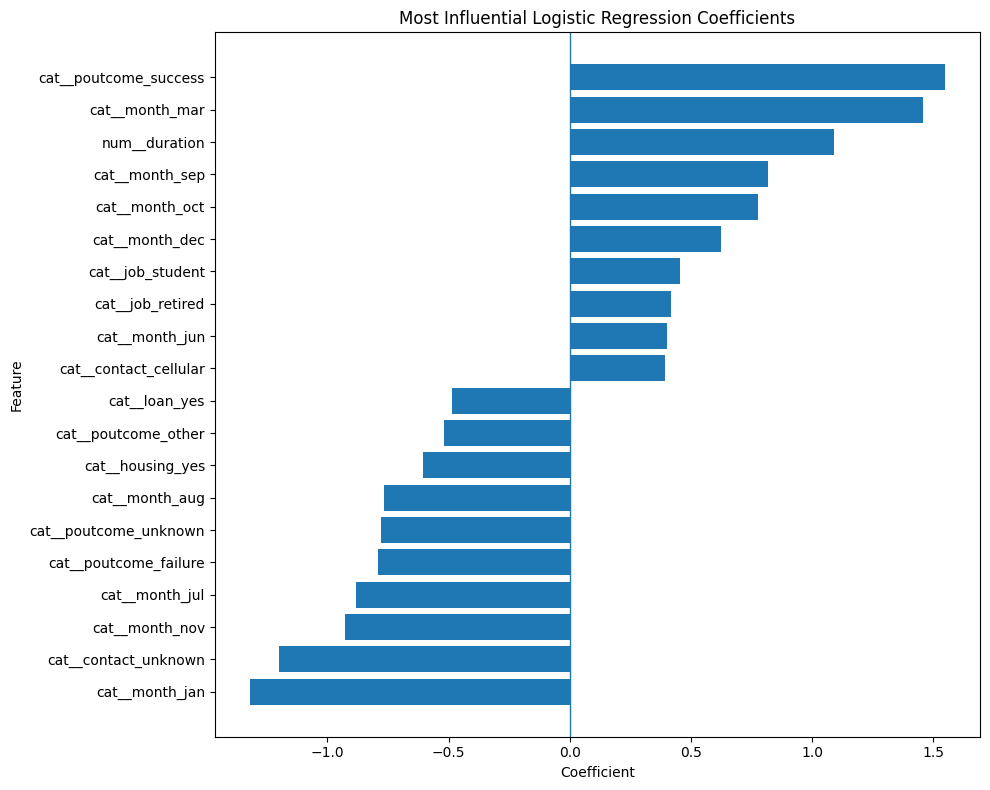

In [19]:
top_coef = pd.concat([
    coef_df.sort_values("Coefficient").head(10),
    coef_df.sort_values("Coefficient").tail(10)
]).drop_duplicates()

plt.figure(figsize=(10, 8))
plt.barh(top_coef["Feature"], top_coef["Coefficient"])
plt.axvline(0, linewidth=1)
plt.title("Most Influential Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 17. Example Prediction for a New Customer

The following example demonstrates how the trained pipeline can predict a new customer's subscription probability.

**Important:** the example values are only for demonstrating model usage.


In [20]:
new_customer = pd.DataFrame([{
    "age": 35,
    "job": "management",
    "marital": "married",
    "education": "tertiary",
    "default": "no",
    "balance": 1500,
    "housing": "yes",
    "loan": "no",
    "contact": "cellular",
    "day": 15,
    "month": "may",
    "duration": 300,
    "campaign": 1,
    "pdays": -1,
    "previous": 0,
    "poutcome": "unknown"
}])

new_probability = logistic_model.predict_proba(new_customer)[0, 1]
new_prediction = "yes" if new_probability >= 0.50 else "no"

print(f"Probability of subscribing: {new_probability:.4f}")
print(f"Predicted subscription     : {new_prediction}")


Probability of subscribing: 0.0862
Predicted subscription     : no


## 18. Conclusion

The Bank Marketing dataset was used to develop a binary classification model with Logistic Regression. Categorical variables were one-hot encoded and numerical variables were standardized inside a preprocessing pipeline.

The model was evaluated using accuracy, precision, recall, F1-score, ROC-AUC, a confusion matrix, and an ROC curve. The coefficient analysis also provides an interpretable view of which encoded features are associated with higher or lower predicted subscription probability.

### Final observation
The target variable is imbalanced, with substantially more `no` responses than `yes` responses. Therefore, **accuracy alone should not be used to judge the model**. Precision, recall, F1-score, ROC-AUC, and the confusion matrix provide a more complete evaluation.

For a real banking deployment, the choice of classification threshold should depend on the business cost of false positives versus false negatives. Also, if the model is intended to make a prediction **before a marketing call takes place**, variables that are only known after/during the call (especially `duration`) should be reconsidered to avoid deployment-time information leakage.
